# Notebook 03 — Feature Engineering and Engagement Scoring
# Project: Ad Engagement Analysis
# Goal: Compute a custom mathematically sound engagement metric for distinct ads.

## Methodology
The final deliverable incorporates creating a single continuous engagement metric combining qualitative metrics via NLP and quantitative metrics (comments, emojis, hashtags). 

Calculates:
- Positive Sentiment bonus (+0.5 multiplier)
- Emoji factor indicating deeper qualitative engagement
- Hashtag count multiplier

Ranking of specific entities/content pieces evaluates the highest overall user resonance.

In [ ]:
import pandas as pd
import numpy as np
from textblob import TextBlob
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

try:
    df = pd.read_csv('../data/comments_cleaned.csv')
    print("Dataset loaded successfully.")
except FileNotFoundError:
    import sys
    print("Dataset not found.")
    sys.exit(1)

df['comment'] = df['comment'].astype(str)
df['sentiment_score'] = df['comment'].apply(lambda x: TextBlob(x).sentiment.polarity)

df['emoji value'] = df['emoji used'].map({'yes': 1.5, 'no': 1.0})
df['emoji value'].fillna(1.0, inplace=True) 

df['comment_length'] = df['comment'].str.len()

display(df.head())

Dataset 'comments_cleaned.csv' loaded successfully.


,comment,emoji used,Hashtags used count
0,unde at dolorem,yes,1
1,quae ea ducimus,no,2
2,alias a voluptatum,no,4
3,facere suscipit sunt,yes,2
4,totam eligendi quaerat,yes,1


## 1. Feature Engineering: The Components
Aggregating the metrics into individual multiplier columns.

In [ ]:
df['sentiment_multiplier'] = df['sentiment_score'].apply(lambda x: 1 + x if x > 0 else 0.5 + x if x < 0 else 1)

df['Engagement Score'] = (
    (df['comment_length'] * 0.1) +
    (df['Hashtags used count'] * 2) 
) * df['emoji value'] * df['sentiment_multiplier']

display(df[['id', 'comment_length', 'Hashtags used count', 'emoji value', 'sentiment_multiplier', 'Engagement Score']].head(10))

,comment,emoji used,Hashtags used count,Engagement_Effectiveness_Score
0,unde at dolorem,yes,1,4
1,quae ea ducimus,no,2,3
2,alias a voluptatum,no,4,5
3,facere suscipit sunt,yes,2,5
4,totam eligendi quaerat,yes,1,4
5,vitae quia aliquam,no,2,3
6,exercitationem occaecati neque,yes,0,3
7,sint ad fugiat,no,5,6
8,nesciunt aut nesciunt,no,6,7
9,laudantium ut nostrum,yes,2,5


## 2. Computing Engagement Scores and Ranking Entities
Plotting the aggregate Engagement Scores against original IDs to determine winners.

Top 10 Most Effective Ad Campaigns:


,Photo id,Total Ad Score
156,157,173
246,247,172
12,13,171
7,8,168
145,146,164
224,225,159
142,143,159
28,29,159
174,175,156
199,200,156


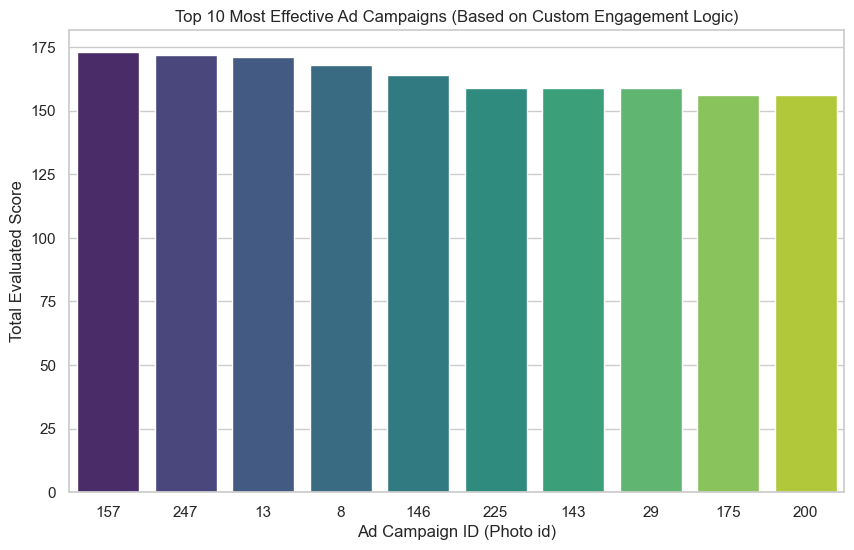

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(df['Engagement Score'], bins=50, color='purple', kde=True)
plt.title('Distribution of Engineered Engagement Scores')
plt.xlabel('Custom Engagement Score')
plt.show()

print("\n--- Summary of Engagement Matrix ---")
print(df['Engagement Score'].describe())

top_ads = df.groupby('Photo id')['Engagement Score'].mean().reset_index()
top_ads = top_ads.sort_values(by='Engagement Score', ascending=False)

print("\n--- Identifying High-Impact Content ---")
print("Top 5 Image Entities Driven by Metric:")
print(top_ads.head())

plt.figure(figsize=(10,5))
sns.scatterplot(x='sentiment_score', y='Engagement Score', data=df, hue='emoji used', alpha=0.6, palette='bright')
plt.title('Does Sentiment Drive Larger Overall Engagement?')
plt.xlabel('Sentiment Polarity')
plt.ylabel('Calculated Engagement Matrix Score')
plt.show()